In [1]:
# add parent to path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from demo_and_analysis.plots.utils.wandb_utils import combine_histories, get_wandb_stats

# tpc-h bespoke storage linearge
run_ids = [
    "jg4jjo9u",
    "86crnuc0",
    "3zdiw9ol",
    "tc2q4e36",
]

hists_list = []
for run_id in run_ids:
    summary, hist, config = get_wandb_stats(
        run_id,
        skip_cache=False,  # set to True to skip cache and fetch from W&B API
        wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
    )
    hists_list.append(hist)


combined_history = combine_histories(hists_list)

Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/21f74321f09a12f51c273f3d499521892dba391dff5ab6eb673a44a7a001b0fa.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/532712d2907861c4bd7972ded9695a464e32cbe45a45dbabc4eab2e998ff5ba3.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/d9d6be482e0f01fd048c076a1ba8d75369053729bbb25c711294920a330b412f.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/55d752d2ee90cd93a69f9555f05f322483f3728feac2a1e47e6c09550c413d76.pkl
Combined history has 15130 rows ([5, 1544, 8310, 5271])


In [2]:
# skip nan
prompts = combined_history["current_prompt"].dropna()
prompts.head()

0      Your task is to analyze the workload and produ...
5      You are an expert database engineer and skille...
57     Finish all todos from previous interaction out...
101    Analyze the build implementation in db_loader....
182    Execute and check termination without error. F...
Name: current_prompt, dtype: str

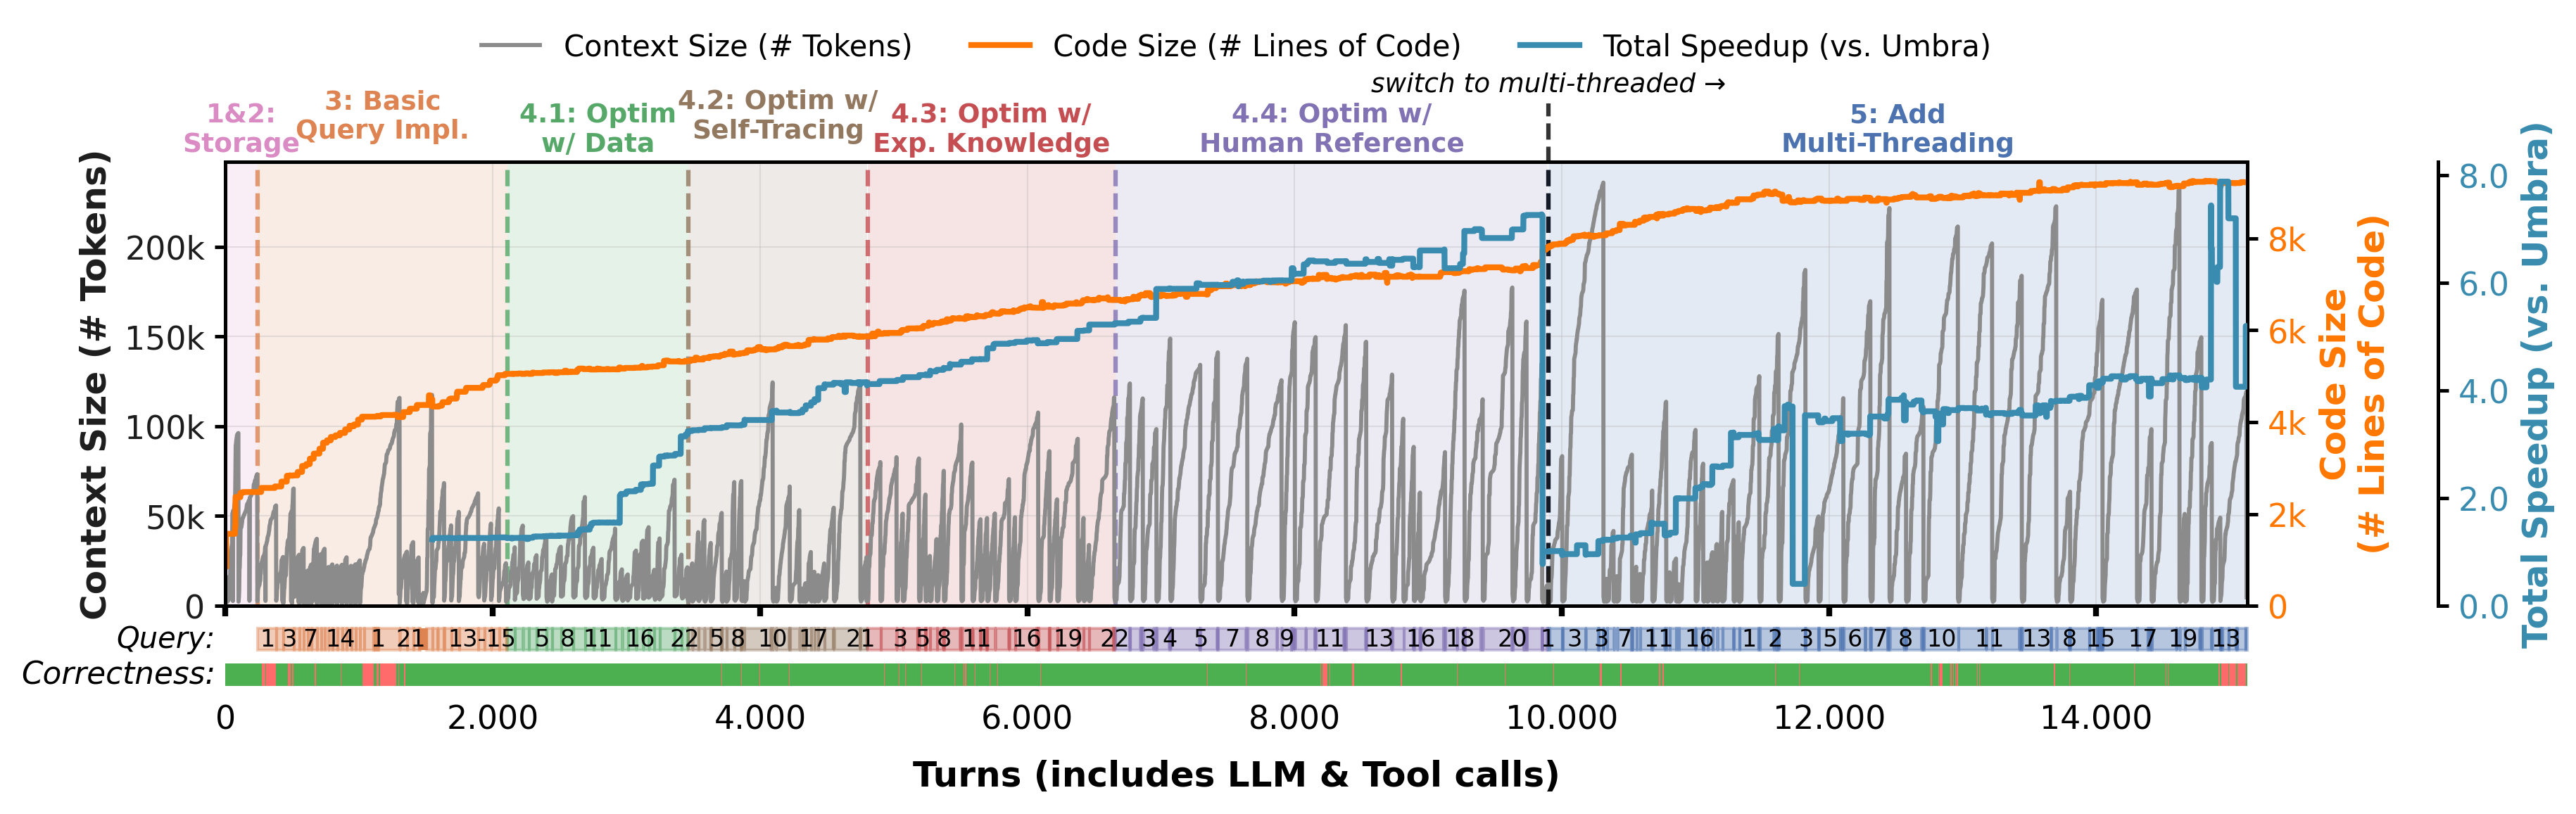

In [11]:
# add parent to path
import sys

sys.path.append(Path.cwd().parent.parent.as_posix())


import importlib

import plot_timeline

importlib.reload(plot_timeline)


from plot_timeline import PlotConfig, TimelineEngine

engine = TimelineEngine(
    combined_history, summary=None, drill_down_to_query_level=True, cmp_to="umbra"
)


config = PlotConfig(
    left_axis_series=["input_tokens"],
    right_axis_series=["code_size"],
    right_axis2_series=["speedup"],
    highlight_correction_span=True,
    figsize=(12, 4),
    legend_y_offset=1.35,
    x_label_pad=8,
    query_row_ymin=-0.1,
)

fig, ax = engine.plot(config)
# save fig

out_path = Path("figures/timeline_plot.pdf")
out_path.parent.mkdir(exist_ok=True)

fig.savefig(out_path, bbox_inches="tight", pad_inches=0.0)

In [4]:
series = engine.worked_on_queries

# convert series to df
df = series.to_frame(name="query").reset_index()
df.head()

,index,query
0,0,"(storage, )"
1,1,"(storage, )"
2,2,"(storage, )"
3,3,"(storage, )"
4,4,"(storage, )"


In [5]:
import re

blacklist = [
    "agent_name",
    "current_hash",
    "current_prompt",
    "shell/commands",
    "type",
]

filtered_keys = []
for key in summary.keys():
    if key.startswith("_"):
        continue

    if key in blacklist:
        continue

    if key.startswith("final"):
        continue

    if key.endswith("_data") or key.endswith("_plot_table"):
        continue

    if key.startswith("validation/total_"):
        continue

    if re.search(r"/query_\d+/", key):
        continue

    filtered_keys.append(key)
    print(key)

print(f"{len(summary.keys())} -> {len(filtered_keys)}")

filtered_keys.append("code_size")
filtered_keys.append("validation/largest_sf_total_speedup")

answered_from_cache
apply_patch/added_loc_count
apply_patch/deleted_loc_count
apply_patch/files
apply_patch/string
cached_tokens
code/loc
code/snapshot_hash
compaction/candidate_items
compaction/output_items
compile/error
compile/truncated
context_window_usage
cost_usd
current_prompt_descriptor
input_tokens
llm/output_text
llm_hash
output_tokens
prompt_idx
real_cost_usd
reasoning_tokens
shell/num_commands
shell/outputs
supervisor
supervisor/approved
timeline_plot
tool/applypatch_count
tool/compaction_count
tool/compile_count
tool/handoff_count
tool/llm_count
tool/shell_count
tool/validate_count
total/cached_tokens
total/cost_usd
total/input_tokens
total/output_tokens
total/real_cost_usd
total/reasoning_tokens
total/runtime
turn
validation/all_queries
validation/avg_speedup
validation/compile_error
validation/compile_with_optimize
validation/core_ids
validation/correct
validation/error
validation/external_call
validation/failed_query_id
validation/ingest_time_ms
validation/instantiation

In [6]:
# from ipywidgets import interact, widgets


# @interact(
#     left_axis_series=widgets.SelectMultiple(
#         options=sorted(filtered_keys),
#         description="Left Axis Series",
#         value=["input_tokens", "reasoning_tokens"],
#     ),
#     right_axis_series=widgets.SelectMultiple(
#         options=sorted(filtered_keys),
#         description="Right Axis Series",
#         value=["code_size"],
#     ),
#     show_corrections=True,
#     show_worked_on=True,
# )
# def update_plot(left_axis_series, right_axis_series, show_corrections, show_worked_on):
#     plot_config = PlotConfig(
#         left_axis_series=left_axis_series,
#         right_axis_series=right_axis_series,
#         highlight_correction_span=show_corrections,
#         highlight_worked_on=show_worked_on,
#     )
#     engine.plot(plot_config)

In [7]:
combined_history

,_runtime,_step,_timestamp,agent_name,answered_from_cache,apply_patch/added_loc_count,apply_patch/create_count,apply_patch/deleted_loc_count,apply_patch/files,apply_patch/string,...,validation/sf100_all_queries_avg_speedup,validation/sf100_all_queries_data,validation/sf100_all_queries_plot_table,validation/sf100_all_queries_total_speedup,validation/sf50_all_queries_avg_speedup,validation/sf50_all_queries_data,validation/sf50_all_queries_plot_table,validation/sf50_all_queries_total_speedup,code_size,validation/largest_sf_total_speedup
0,18.088542,0,1.779413e+09,Bespoke Assistant (generate storage plan),False,NaN,NaN,NaN,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,846,NaN
1,174.994420,1,1.779413e+09,NaN,None,NaN,NaN,NaN,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,846,NaN
2,175.169678,2,1.779413e+09,Bespoke Assistant (generate storage plan),False,NaN,NaN,NaN,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,846,NaN
3,201.469195,3,1.779413e+09,NaN,None,447.0,1.0,0.0,[storage_plan.txt],=== CREATING: /home/jwehrstein/bespoke_olap/ou...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,846,NaN
4,213.557795,4,1.779413e+09,Bespoke Assistant (generate storage plan),False,NaN,NaN,NaN,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,846,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15125,181.420294,15122,1.780314e+09,Bespoke Assistant (Check SF100),True,NaN,NaN,NaN,None,NaN,...,NaN,None,None,NaN,NaN,None,None,NaN,9222,6.128367
15126,181.451836,15123,1.780314e+09,NaN,None,NaN,NaN,NaN,None,NaN,...,NaN,None,None,NaN,53.150873,"{'_type': 'table-file', 'log_mode': 'IMMUTABLE...","{'_type': 'table-file', 'sha256': 'c8faef5b326...",0.555762,9222,6.128367
15127,181.482403,15124,1.780314e+09,Bespoke Assistant (Check SF100),True,NaN,NaN,NaN,None,NaN,...,NaN,None,None,NaN,NaN,None,None,NaN,9222,6.128367
15128,404.618284,15125,1.780314e+09,Supervision Agent,True,NaN,NaN,NaN,None,NaN,...,NaN,None,None,NaN,NaN,None,None,NaN,9222,6.128367


In [8]:
for idx, row in engine.worked_on_queries.items():
    print(idx, row)

0 ('storage', '')
1 ('storage', '')
2 ('storage', '')
3 ('storage', '')
4 ('storage', '')
5 ('storage', '')
6 ('storage', '')
7 ('storage', '')
8 ('storage', '')
9 ('storage', '')
10 ('storage', '')
11 ('storage', '')
12 ('storage', '')
13 ('storage', '')
14 ('storage', '')
15 ('storage', '')
16 ('storage', '')
17 ('storage', '')
18 ('storage', '')
19 ('storage', '')
20 ('storage', '')
21 ('storage', '')
22 ('storage', '')
23 ('storage', '')
24 ('storage', '')
25 ('storage', '')
26 ('storage', '')
27 ('storage', '')
28 ('storage', '')
29 ('storage', '')
30 ('storage', '')
31 ('storage', '')
32 ('storage', '')
33 ('storage', '')
34 ('storage', '')
35 ('storage', '')
36 ('storage', '')
37 ('storage', '')
38 ('storage', '')
39 ('storage', '')
40 ('storage', '')
41 ('storage', '')
42 ('storage', '')
43 ('storage', '')
44 ('storage', '')
45 ('storage', '')
46 ('storage', '')
47 ('storage', '')
48 ('storage', '')
49 ('storage', '')
50 ('storage', '')
51 ('storage', '')
52 ('storage', '')
53 